In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold

# Random Forest - Случайный лес

In [2]:
FILE_PATH = Path('Housing.csv')
data = pd.read_csv(FILE_PATH)

In [3]:
data.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850.0,3,1,2,yes,no,yes,no,no,1.0,no
1,2,38500,4000.0,2,1,1,yes,no,no,no,no,0.0,no
2,3,49500,3060.0,3,1,1,yes,no,no,no,no,0.0,no
3,4,60500,6650.0,3,1,2,yes,yes,no,no,no,0.0,no
4,5,61000,6360.0,2,1,1,yes,no,no,no,no,0.0,no


In [4]:
data.dtypes

rownames      int64
price         int64
lotsize     float64
bedrooms      int64
bathrms       int64
stories       int64
driveway        str
recroom         str
fullbase        str
gashw           str
airco           str
garagepl    float64
prefarea        str
dtype: object

In [5]:
data.shape

(546, 13)

In [6]:
data.isna().sum()

rownames    0
price       0
lotsize     5
bedrooms    0
bathrms     0
stories     0
driveway    2
recroom     4
fullbase    0
gashw       2
airco       7
garagepl    2
prefarea    2
dtype: int64

In [7]:
data.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,541.000000,546.000000,546.000000,546.000000,544.000000
mean,273.500000,68121.597070,5160.611830,2.965201,1.285714,1.807692,0.694853
std,157.760895,26702.670926,2175.141222,0.737388,0.502158,0.868203,0.861864
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3584.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
target_col = 'price'
y = data[target_col].values
X = data.drop(columns=[target_col, 'rownames'])

In [9]:
X.head()

,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,5850.0,3,1,2,yes,no,yes,no,no,1.0,no
1,4000.0,2,1,1,yes,no,no,no,no,0.0,no
2,3060.0,3,1,1,yes,no,no,no,no,0.0,no
3,6650.0,3,1,2,yes,yes,no,no,no,0.0,no
4,6360.0,2,1,1,yes,no,no,no,no,0.0,no


In [10]:
target_col

'price'

In [11]:
numeric_features = (X.select_dtypes(include='number').columns.tolist())
categorial_features = (X.select_dtypes(exclude=np.number).columns.tolist())

In [12]:
numeric_features

['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl']

In [13]:
categorial_features

['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

In [14]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorial_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorial_transformer, categorial_features)
    ]
)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
gbr = GradientBoostingRegressor(random_state=42)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gbr', gbr)
])

param_grid = {
    'gbr__n_estimators': [400],
    'gbr__learning_rate': [0.05],
    'gbr__max_depth': [2, 3, 4],
    'gbr__min_samples_split': [2, 5, 10],
    'gbr__min_samples_leaf': [1, 2, 5],
    'gbr__subsample': [1.0, 0.8],
}

In [29]:
cv = KFold(n_splits=5, random_state=42, shuffle=True)
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
grid_search.best_params_

{'gbr__learning_rate': 0.05,
 'gbr__max_depth': 2,
 'gbr__min_samples_leaf': 2,
 'gbr__min_samples_split': 10,
 'gbr__n_estimators': 400,
 'gbr__subsample': 0.8}

In [30]:
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

y_pred_test = best_model.predict(X_test)

print(f"""
Target: {target_col}
Best params: {grid_search.best_params_}
RMSE: {rmse(y_test, y_pred_test):.4f}
R2_score: {r2_score(y_test, y_pred_test):.2f}
""")


Target: price
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 2, 'gbr__min_samples_leaf': 2, 'gbr__min_samples_split': 10, 'gbr__n_estimators': 400, 'gbr__subsample': 0.8}
RMSE: 15379.9334
R2_score: 0.65



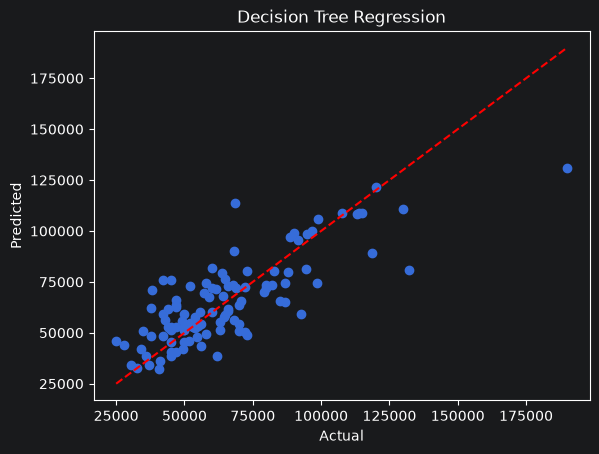

In [31]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title('Decision Tree Regression')
low = min(y_test.min(), y_pred_test.min())
high = max(y_test.max(), y_pred_test.max())
plt.plot([low, high], [low, high], 'r--')
plt.show()

In [32]:
oh = None
if categorial_features:
    oh = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
num_names = numeric_features
cat_names = oh.get_feature_names_out(categorial_features).tolist() if oh is not None else []
feature_names = num_names + cat_names
feature_names

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'garagepl',
 'driveway_no',
 'driveway_yes',
 'recroom_no',
 'recroom_yes',
 'fullbase_no',
 'fullbase_yes',
 'gashw_no',
 'gashw_yes',
 'airco_no',
 'airco_yes',
 'prefarea_no',
 'prefarea_yes']

In [34]:
importances = best_model.named_steps['gbr'].feature_importances_
imp_df = (pd.DataFrame(
    {
        'feature': feature_names if len(feature_names) == len(importances) else [f'feature_{i}' for i in range(len(importances))],
        'importance': importances
    }
).sort_values(by='importance', ascending=False).head(10)
)
imp_df

,feature,importance
0,lotsize,0.463067
2,bathrms,0.150557
4,garagepl,0.092095
3,stories,0.066520
13,airco_no,0.051053
14,airco_yes,0.050678
1,bedrooms,0.024151
10,fullbase_yes,0.018186
16,prefarea_yes,0.013510
9,fullbase_no,0.012937


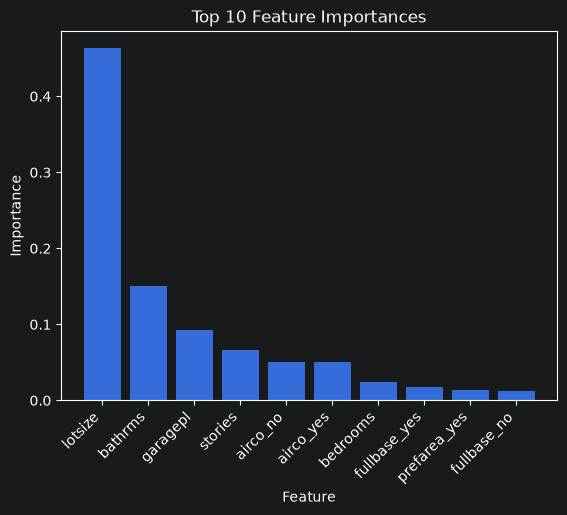

In [35]:
plt.figure()
plt.bar(imp_df['feature'], imp_df['importance'])
plt.title('Top 10 Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.show()